**0. Import requireed modules**

In [ ]:
!git clone https://github.com/lhusemann/ds_for_se_a1.git
!git clone https://github.com/apache/lucene.git
!cd lucene && git checkout releases/lucene/9.0.0
!pip install -U tokenizers transformers accelerate bitsandbytes

fatal: destination path 'ds_for_se_a1' already exists and is not an empty directory.
fatal: destination path 'lucene' already exists and is not an empty directory.
HEAD is now at 0b18b3b965c LUCENE-10234: update smoke-tester with new module names.
  Using cached tokenizers-0.23.1-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.8 kB)


In [ ]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from google.colab import userdata
from pathlib import Path
import re
import json

**1. Provide the path of java files and load their source code into a list**

In [ ]:
PATH_TO_LIST_WITH_RELEVANT_FILES = Path("/content/ds_for_se_a1/misc/Week3_filtering/relevant-files.json")

with open(PATH_TO_LIST_WITH_RELEVANT_FILES, "r") as f:
    relevant_files = set(json.load(f))

In [ ]:
SOURCE_CODE_DIR = Path("/content/lucene/lucene/codecs")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def remove_license_header(content: str) -> str:
    # Removes the first /* ... */ Comment at the beginning of a file
    return re.sub(r'^\s*/\*.*?\*/\s*', '', content, count=1, flags=re.DOTALL)


files_list = []
files_names = [] # File names are unique
# .rglob() searches the root folder and all sub-folders automatically
# .glob() searches only the current directory
for file_path in SOURCE_CODE_DIR.rglob('*.java'):
    if file_path.is_file() and (file_path.name in relevant_files):
        files_names.append(file_path.name)
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            files_list.append(remove_license_header(content))

In [ ]:
len(files_list)

57

**2. Retrieve the Hugging Face token securely from Colab's "Secrets" tab (the key icon on the left).**

In [ ]:
try:
    hf_token = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    print("WARNING: 'HF_TOKEN' not found in Colab Secrets.")
    hf_token = None

**3. Hardware optimization (Quantization)**

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, # What is loaded in 4 bit? why?
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

**4. Generate embeddings**

In [ ]:
embedding_model_name = "Qodo/Qodo-Embed-1-7B"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(embedding_model_name,token=hf_token)
model = AutoModel.from_pretrained(embedding_model_name,token=hf_token,quantization_config=bnb_config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/893 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/370 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2Model(
  (embed_tokens): Embedding(151646, 3584)
  (layers): ModuleList(
    (0-27): 28 x Qwen2DecoderLayer(
      (self_attn): Qwen2Attention(
        (q_proj): Linear4bit(in_features=3584, out_features=3584, bias=True)
        (k_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
        (v_proj): Linear4bit(in_features=3584, out_features=512, bias=True)
        (o_proj): Linear4bit(in_features=3584, out_features=3584, bias=False)
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
        (up_proj): Linear4bit(in_features=3584, out_features=18944, bias=False)
        (down_proj): Linear4bit(in_features=18944, out_features=3584, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((3584,), eps=1e-06)
  (rotary_emb): Qwen2RotaryEmbedding()
)

**5. Construct the semantic similarity matrix**

In [ ]:
def mean_pool(token_embeddings, attention_mask):
    # Expand mask to match embedding dimensions, then zero out padding tokens
    mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * mask_expanded, dim=1) / torch.clamp(mask_expanded.sum(dim=1), min=1e-9)

def embed_source_code(code_files):
    embeddings = []
    for code in code_files:

        # Max length 512 (for current model and available memory size)
        inputs = tokenizer(code, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        # Extract the embedding vector via mean pooling
        embedding = mean_pool(outputs.last_hidden_state, inputs["attention_mask"])

        # Move to CPU and convert to numpy
        embeddings.append(embedding.cpu().numpy())

    return np.vstack(embeddings)

In [ ]:
embeddings = embed_source_code(files_list)
semantic_matrix = cosine_similarity(embeddings)

**6. Construct the structural similarity matrix**

In [ ]:
# scan the filtered .rsf dependency file from week 1 to construct a matrix where each entry is the number of packages each pair of files depend on.
# executing this cell produces 'struct_matrix_raw'

SUFFIX = ".java"
file_to_files = {} # Dict of Set
filtered_rsf_path = Path("/content/ds_for_se_a1/filtered.rsf")

# Parse rsf file
with open(filtered_rsf_path, "r") as file:
    for line in file:
        parts = line.strip().split()
        if len(parts) != 3 or parts[0] != "depends":
            continue

        source, target = parts[1], parts[2]
        # Since files are needed but the rsf file lists per class, the syntax is mainclass$otherclass, so split and take first
        # Then remove package and only take the class/file name, and append file suffix
        source = source.split("$")[0].split(".")[-1] + SUFFIX
        target = target.split("$")[0].split(".")[-1] + SUFFIX

        # Self-referencing classes within a file should be ignored
        if source == target:
            continue

        if source not in file_to_files:
            file_to_files[source] = set()

        file_to_files[source].add(target)

file_to_depscount = {} # Dict of list of tuple(string <the other element>, int <count>)

for file, files in file_to_files.items():
    file_to_depscount[file] = []
    for file_2, files_2 in file_to_files.items():
        # Don't count self<->self since they are not necessarily equal across all files.
        # The next cell normalizes and THEN sets diagonal to 1, which would lead to incorrect numbers overall
        if file == file_2:
            continue

        count = len(files.intersection(files_2))

        # detect bidirectional dependencies
        if file_2 in files and file in files_2:
            count += 1

        if count == 0:
            continue

        file_to_depscount[file].append((file_2, count))

# There will be some files like org.apache.lucene.codecs.simpletext.SimpleTextUtil missing as they do not appear on the left side of the rsf
# As it has no references to other files within codecs (which is the package of interest)
# So the entries will be 0

# Use files_names to index the matrix, using data from file_to_files
size = len(files_names)
struct_matrix_raw = np.zeros((size, size))

for file, depscount in file_to_depscount.items():
    if file not in files_names:
        continue

    file_index = files_names.index(file)

    for (other, count) in depscount:
        if other not in files_names:
            continue

        other_index = files_names.index(other)
        # Matrix is symmetric by definition of the task
        struct_matrix_raw[file_index, other_index] = count
        struct_matrix_raw[other_index, file_index] = count

print(f"struct_matrix_raw Done ({size}x{size})")

struct_matrix_raw Done (57x57)


**7. Normalize the structural matrix**

In [ ]:
max_overlap = struct_matrix_raw.max()
struct_matrix = struct_matrix_raw / max_overlap if max_overlap > 0 else struct_matrix_raw
np.fill_diagonal(struct_matrix, 1.0)

**8. Combine the two matrices into one similarity matrix then apply complement.**

In [ ]:
# ALPHA dictates the weight of structural vs. semantic data.
# E.g., 0.4 means 40% Structural (RSF) and 60% Semantic (CodeBERT)
ALPHA = 0.25
combined_similarity = (ALPHA * struct_matrix) + ((1 - ALPHA) * semantic_matrix)

# Invert similarity to get distance
distance_matrix = 1.0 - combined_similarity
np.fill_diagonal(distance_matrix, 0)

**9. Apply clustering**

In [ ]:
TARGET_NUM_CLUSTERS = 20 # Integer k, with 1 < k < N (N = Amount of files). in our case 57
linkageValue = 'average'
clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric='precomputed', linkage=linkageValue) # what is 'precomputed' & 'linkage'?
clusters = clusterer.fit_predict(distance_matrix)


In [ ]:
rsf_name = f"Qodo_codecs_a{int(ALPHA * 10):03d}_c{TARGET_NUM_CLUSTERS}_{linkageValue}.rsf"
rsf_output_path = OUTPUT_DIR / rsf_name

with open(rsf_output_path, 'w') as f:
    for file, cluster in sorted(zip(files_names, clusters), key=lambda x: x[1]):
        line = f"contain {cluster} {file}"
        print(line)
        f.write(line + "\n")

print(f"\nRSF file written to {rsf_output_path}")

contain 0 SimpleTextSegmentInfoFormat.java
contain 0 SimpleTextStoredFieldsWriter.java
contain 0 SimpleTextLiveDocsFormat.java
contain 0 SimpleTextFieldInfosFormat.java
contain 0 SimpleTextCompoundFormat.java
contain 0 SimpleTextDocValuesWriter.java
contain 0 SimpleTextTermVectorsWriter.java
contain 0 SimpleTextDocValuesReader.java
contain 1 FSTOrdsOutputs.java
contain 1 FSTTermOutputs.java
contain 2 BloomFilteringPostingsFormat.java
contain 2 BlockTermsReader.java
contain 2 BlockTermsWriter.java
contain 2 SimpleTextPostingsFormat.java
contain 2 BlockTreeOrdsPostingsFormat.java
contain 2 OrdsBlockTreeTermsWriter.java
contain 2 FSTTermsWriter.java
contain 2 FSTTermsReader.java
contain 2 FSTPostingsFormat.java
contain 2 DirectPostingsFormat.java
contain 3 VariableGapTermsIndexWriter.java
contain 3 FixedGapTermsIndexWriter.java
contain 3 FixedGapTermsIndexReader.java
contain 3 VariableGapTermsIndexReader.java
contain 4 SimpleTextPointsFormat.java
contain 4 SimpleTextBKDReader.java
contain

**10. Visulizations**

In [ ]:
# According to the applied algorithm documentation, provide any visualizations for better understanding of how the clusters are formed.

**Dendrogramm**


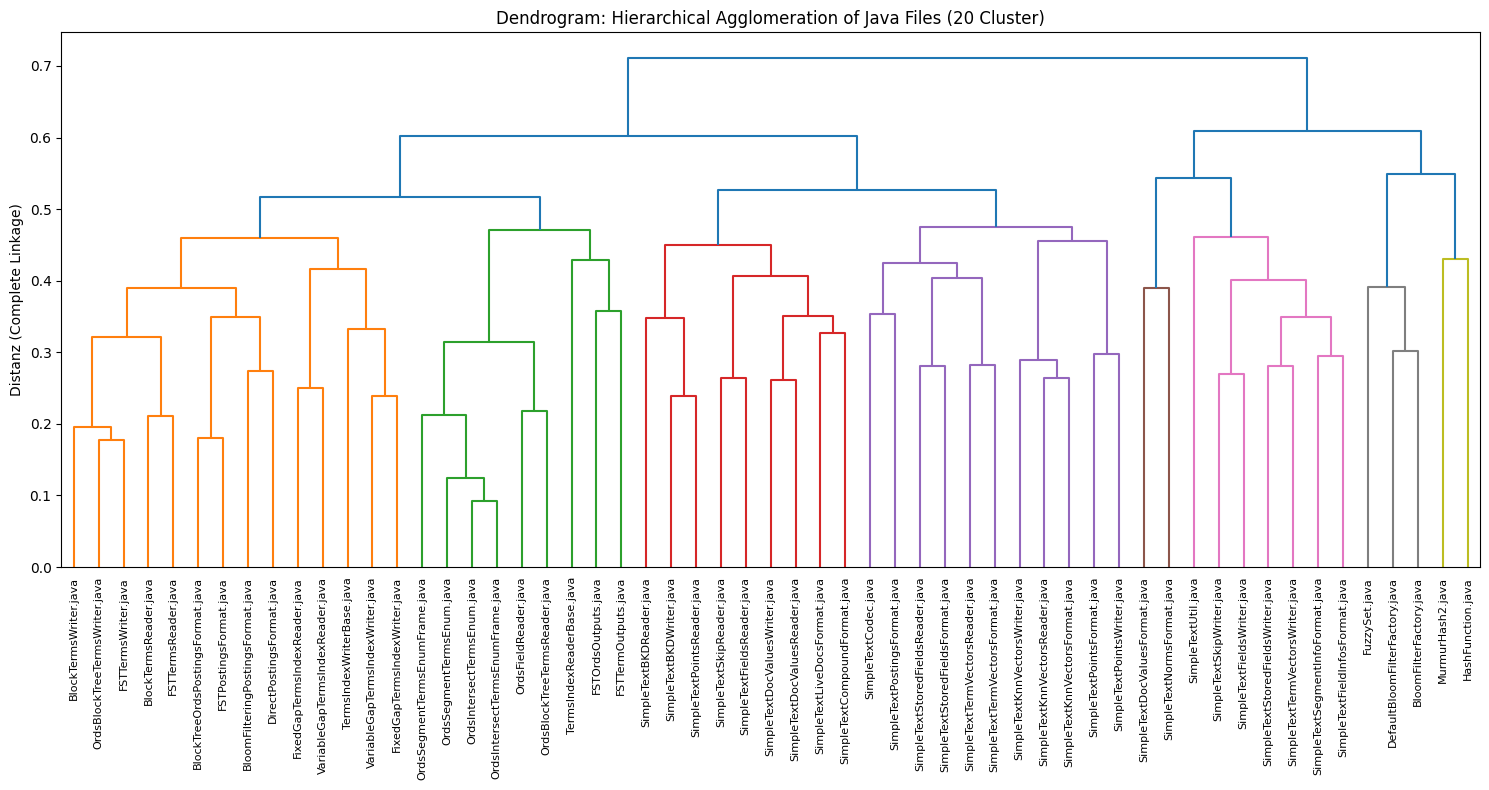

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Umwandlung der redundanten NxN Matrix in ein kondensiertes Distanz-Array für SciPy
condensed_dist = squareform(distance_matrix)

# Linkage-Matrix berechnen (method muss mit dem 'linkage' von scikit-learn übereinstimmen)
Z = linkage(condensed_dist, method='complete')

plt.figure(figsize=(15, 8))
dendrogram(Z, labels=files_names, leaf_rotation=90, leaf_font_size=8)
plt.title(f"Dendrogram: Hierarchical Agglomeration of Java Files ({TARGET_NUM_CLUSTERS} Cluster)")
plt.ylabel("Distanz (Complete Linkage)")
plt.tight_layout()


dendro_name = f"Qodo_codecs_a{int(ALPHA * 100):03d}_c{TARGET_NUM_CLUSTERS}_{linkageValue}.png"
rsf_output_path = OUTPUT_DIR / dendro_name

# 2. Speichern der Grafik
plt.savefig(
    rsf_output_path,
    dpi=300,            # Höhere Auflösung für Publikationen/Dokumentation
    bbox_inches='tight', # Verhindert das Abschneiden von Labels (wichtig bei leaf_rotation=90)
    format='png'        # Explizite Formatangabe (optional, wird aus Extension inferiert)
)
plt.show()

**Cluster Map**

**Multi-Dimensional Scaling (MDS) Projektion**

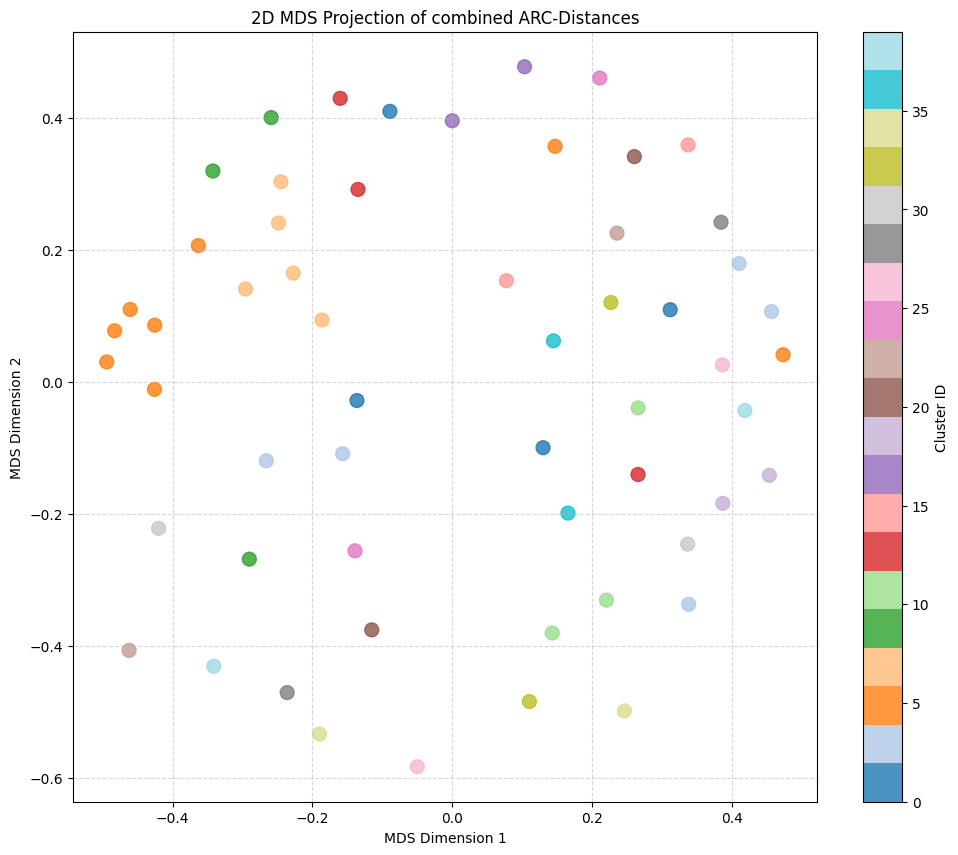

In [ ]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# dissimilarity='precomputed' ist hier zwingend
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords = mds.fit_transform(distance_matrix)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='tab20', s=100, alpha=0.8)

# Optional: Annotiere die Punkte mit den Dateinamen (kann bei >50 Files unübersichtlich werden)
# for i, txt in enumerate(files_names):
#     plt.annotate(txt[:10]+"..", (coords[i, 0], coords[i, 1]), fontsize=6)

plt.colorbar(scatter, label='Cluster ID')
plt.title("2D MDS Projection of combined ARC-Distances")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Automized gathering of data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
OUTPUT_DIR = Path("/content/drive/MyDrive/Qodo/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

target_cluster_range = [50,57]
linkage_value_range = ['complete', 'average']
alpha_range = [0.25, 0.5, 0.75]

for alpha in alpha_range:
    # 1. Ebene: Abhängig von ALPHA
    # Gewichtung und Distanzmatrix berechnen
    combined_similarity = (alpha * struct_matrix) + ((1 - alpha) * semantic_matrix)
    distance_matrix = 1.0 - combined_similarity
    np.fill_diagonal(distance_matrix, 0)
    alpha_str = f"{int(alpha * 100):03d}"

    # Kondensierte Distanz für SciPy-Dendrogramm (nur 1x pro Alpha nötig)
    condensed_dist = squareform(distance_matrix)

    for linkage_val in linkage_value_range:
        # 2. Ebene: Abhängig von ALPHA und LINKAGE
        # SciPy Linkage-Matrix berechnen (method dynamisch an linkage_val angepasst)
        Z = linkage(condensed_dist, method=linkage_val)


        # --- Dendrogram Plot ---
        plt.figure(figsize=(15, 8))
        dendrogram(Z, labels=files_names, leaf_rotation=90, leaf_font_size=8)
        plt.title(f"Dendrogram: Hierarchical Agglomeration of Java Files")
        plt.ylabel(f"Distanz ({linkage_val.capitalize()} Linkage)")
        plt.tight_layout()

        dendro_name = f"Qodo_codecs_a{alpha_str}_{linkage_val}.png"
        png_output_path = OUTPUT_DIR / dendro_name

        plt.savefig(
            png_output_path,
            dpi=300,
            bbox_inches='tight',
            format='png'
        )
        # WICHTIG: Figure schließen, sonst kommt es bei 36 Iterationen zum Out-of-Memory
        plt.close()
        for target_clusters in target_cluster_range:
            # 3. Ebene: Abhängig von ALPHA, LINKAGE und CLUSTERS

            # --- Sklearn Clustering ---
            clusterer = AgglomerativeClustering(
                n_clusters=target_clusters,
                metric='precomputed',
                linkage=linkage_val
            )
            clusters = clusterer.fit_predict(distance_matrix)

            # --- RSF Export ---

            rsf_name = f"Qodo_codecs_a{alpha_str}_c{target_clusters}_{linkage_val}.rsf"
            rsf_output_path = OUTPUT_DIR / rsf_name

            with open(rsf_output_path, 'w') as f:
                for file, cluster in sorted(zip(files_names, clusters), key=lambda x: x[1]):
                    line = f"contain {cluster} {file}"
                    f.write(line + "\n")

            print(f"Generated: {rsf_name}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Generated: Qodo_codecs_a025_c10_complete.rsf
Generated: Qodo_codecs_a025_c20_complete.rsf
Generated: Qodo_codecs_a025_c30_complete.rsf
Generated: Qodo_codecs_a025_c40_complete.rsf
Generated: Qodo_codecs_a025_c50_complete.rsf
Generated: Qodo_codecs_a025_c57_complete.rsf
Generated: Qodo_codecs_a025_c10_average.rsf
Generated: Qodo_codecs_a025_c20_average.rsf
Generated: Qodo_codecs_a025_c30_average.rsf
Generated: Qodo_codecs_a025_c40_average.rsf
Generated: Qodo_codecs_a025_c50_average.rsf
Generated: Qodo_codecs_a025_c57_average.rsf
Generated: Qodo_codecs_a050_c10_complete.rsf
Generated: Qodo_codecs_a050_c20_complete.rsf
Generated: Qodo_codecs_a050_c30_complete.rsf
Generated: Qodo_codecs_a050_c40_complete.rsf
Generated: Qodo_codecs_a050_c50_complete.rsf
Generated: Qodo_codecs_a050_c57_complete.rsf
Generated: Qodo_codecs_a050_c10_average.rsf
Generated: Qodo_codecs_